Energy sample values: [[17.28316619 17.17970838 16.73450333 17.18826805 15.89121719]
 [17.68147797 17.2098893  16.75963839 16.15024377 16.53568337]
 [15.55087836 16.29562604 17.66977509 17.89420165 18.09757057]
 [15.972644   15.40667255 17.4008518  19.17336319 19.32284311]
 [16.63139072 16.63033836 17.46943915 19.69648328 19.62380415]]
Orientation sample values: [[0.5649289  2.05078919 0.89438542 1.44409755 0.73526572]
 [0.81178257 0.84193316 1.34272781 2.44671527 2.37343055]
 [0.6567979  1.65413909 1.94992492 1.03746701 0.45365609]
 [2.32603641 1.02139301 0.85292808 0.79233281 0.76202469]
 [0.28694664 2.40905899 1.39997914 0.87933376 0.92856277]]
Coherence sample values: [[0.65128289 0.63321999 0.73478494 0.82307374 0.67510775]
 [0.80923475 0.76614136 0.79206321 0.41999881 0.44226711]
 [0.68482444 0.7641967  0.59575752 0.82580965 0.74508881]
 [0.51082404 0.74509102 0.7612634  0.79884312 0.86052818]
 [0.63431383 0.46677204 0.76612991 0.87208829 0.94543204]]
Frequency sample values: [[1

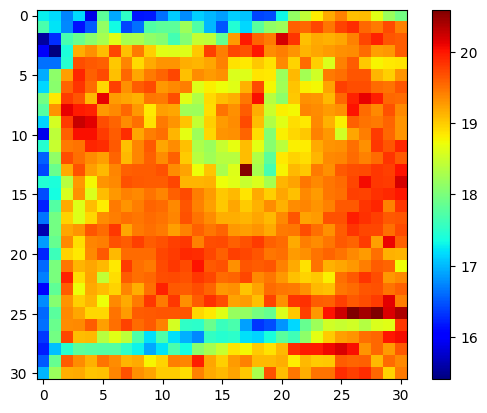

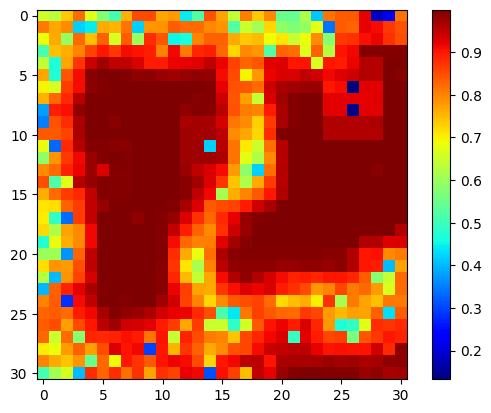

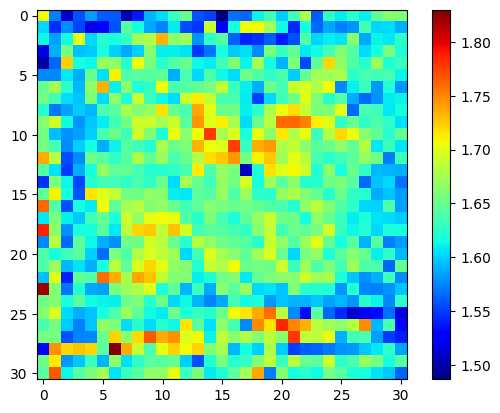

In [ ]:
import cv2
import numpy as np
from afqa_toolbox.enhancement import GaborEnhancement, Energy
from afqa_toolbox.tools.common import normed, resized
from afqa_toolbox.tools.visualization import visualize_orientation_field 
import matplotlib.pyplot as plt
from scipy.fftpack import fft2
import scipy.io as sio
 
# Constants
NFFT = 32  # Size of FFT
BLKSZ = 16  # Block size
OVRLP = 8  # Overlap size
RMIN = 5  # Min allowable ridge spacing
RMAX = 20  # Max allowable ridge spacing

# Load fingerprint image
latent = "/home/ricardoatriana/STFT/finger.png"  # Update with correct image path
image = cv2.imread(latent, 0)

# Compute STFT maps
eimg, oimg, cimg, fimg, fftSrc, bwimg = Energy.compute_energy_and_orientation(image, NFFT, BLKSZ, OVRLP, RMAX, RMIN)

print(f"oimg shape: {oimg.shape}, bwimg shape: {bwimg.shape}")

# Reconstruct the fingerprint image using stored FFT coefficients
reconstructed_img = Energy.reconstruct_from_fft(fftSrc, NFFT, BLKSZ, OVRLP, image.shape)

# Visualize orientation field
orientation_map = visualize_orientation_field(image, oimg, blk_size=BLKSZ)

# Visualization
plt.imshow(eimg, cmap='jet')
plt.colorbar()
plt.show()

plt.imshow(cimg, cmap='jet')
plt.colorbar()
plt.show()

plt.imshow(fimg, cmap='jet')
plt.colorbar()
plt.show()

cv2.imshow("Flipped Orientation Map", orientation_map)

cv2.imshow("Enhanced Fingerprint", reconstructed_img)

cv2.waitKey(0)
cv2.destroyAllWindows()